In [72]:
from numba import jit, njit
import kwant
from kwant.digest import uniform    # a (deterministic) pseudorandom number generator
import kwant.kpm


import scipy

import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace

from scipy.ndimage import gaussian_filter


import cmath

from qutip import *
from joblib import Parallel, delayed

from numba import njit, prange
from numba import set_num_threads, get_num_threads


# --- Labels ---
font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}

In [73]:
def gate_U(vx, d):
    UL = 0  #in meV
    UR = 0
    
    vUG = (UR+UL)/2. + (UR-UL)/np.pi*np.arctan(vx/d)
    
    return vUG

def donor_U(vx, d, E0):
    vDonors = np.zeros(len(vx))
    #E0 = 4377 #in meV
    vDonors = - E0 * (1-vx**2/d**2)**.5
    return vDonors
    
def kernel(vx, vt, d):
    l_cut = 2.  #in nm
    mx, mt = np.meshgrid( vx, vt, indexing='ij' ) # indexed as m[nx,ny]
    md = d * np.ones(shape=(len(vx), len(vt)))
    mK = np.log( np.abs( (np.sqrt( (d**2 - mx**2.)*(d**2.-mt**2) ) + d**2 - mx*mt )/(2*d**2) ) ) - np.log( np.abs((mx-mt + 1e-12)/(2*d)) )*(1-np.exp(-np.abs(mx-mt)/l_cut ))    
    
    return mK - np.amin(mK)*0

def kernel_1D_image(vx, vt, d, dedge):
    
    mx, mt = np.meshgrid( vx, vt, indexing='ij' ) # indexed as m[nx,ny]
    md = d * np.ones(shape=(len(vx), len(vt)))
    mdedge = dedge * np.ones(shape=(len(vx), len(vt)))
    l_cut = 2.  #in nm
        
    #mK = np.log( np.abs( (np.sqrt( (md**2 - mx**2.)*(md**2.-mt**2) ) + d**2 - mx*mt )/(mx-mt + 1e-7)/md ) ) 
    #mK += np.log( np.abs( mx + mt - 2*md - 2*mdedge + 1e-7 ) )
    
    #mK = - ( np.log( np.abs( mx - mt + 1e-7 ) )*(1-np.exp(-np.abs(mx-mt)/l_cut )) - np.log( np.abs( mx + mt - 2*md - 2*mdedge + 1e-7 ) )  ) 
    #mK = - ( np.log( np.abs( mx - mt + 1e-10 ) )*(1-np.exp(-np.abs(mx-mt)/l_cut )) - np.log( np.sqrt( (mx - mt)**2 + (2*mdedge)**2 + 1e-10 ) )  ) 
    mK = - np.log( np.abs( mx - mt + 1e-12 ) )*(1-np.exp(-np.abs(mx-mt)/l_cut )) + np.log( np.abs( mx + mt - 2*md - 2*mdedge + 1e-12 ) ) + 0*np.log( np.sqrt( (mx - mt)**2 + (2*3400)**2 + 1e-10 ) )   
    
    return mK - np.amin(mK)

def kernel_1D_0(vx, vt, d):
    
    mx, mt = np.meshgrid( vx, vt, indexing='ij' ) # indexed as m[nx,ny]
    md = d * np.ones(shape=(len(vx), len(vt)))
    l_cut = 1  #in nm
    mK = - np.log( np.abs( mx - mt + 1e-12 )/(d) )*(1-np.exp(-np.abs(mx-mt)/l_cut ))    
    
    return mK - np.amin(mK)

def kernel_3D(vx, vt, d, sides, dedge):
    
    mx, mt = np.meshgrid( vx, vt, indexing='ij' ) # indexed as m[nx,ny]
    mK = np.zeros(shape=(len(vx), len(vt)))
    
    l_cut = .1  #in nm
    if sides == 2:
        for m in range(-100,100):
            mK += (1./np.abs( mx - mt - 4*d*m + 1e-7 ) - 1./np.abs( mx + mt + 2*d - 4*d*m + 1e-7 ) ) * (1-np.exp(-np.abs(mx-mt)/l_cut ))   #smooth UV cutoff at l_cut in nm
    elif sides == 1:
        #m = 1
        #mK = (1./np.abs( mx - mt + 1e-7 ) - 1./np.abs( mx + mt + 2*d - 4*d*m + 1e-7 ) ) * (1-np.exp(-np.abs(mx-mt)/l_cut ))   #smooth UV cutoff at l_cut in nm
        
        #mK = (1./np.abs( mx - mt + 1e-7 ) - 1./np.abs( mx + mt + 2*d + 2*dedge + 1e-7 ) ) * (1-np.exp(-np.abs(mx-mt)/l_cut ))   #smooth UV cutoff at l_cut in nm   LEFT
        mK = (1./np.abs( mx - mt + 1e-7 )* (1-np.exp(-np.abs(mx-mt)/l_cut )) - 1./np.abs( mx + mt - 2*d - 2*dedge + 1e-7 ) )   #smooth UV cutoff at l_cut in nm      RIGHT
    elif sides == 0:
        m = 1
        mK = (1./np.abs( mx - mt + 1e-7 ) ) * (1-np.exp(-np.abs(mx-mt)/l_cut ))   #smooth UV cutoff at l_cut in nm
    return mK - np.amin(mK)

def int_donor_U(vx, d, mK, n0, U0):
    vDonors = np.zeros(len(vx))
    dx = np.abs(vx[0]-vx[1])
    vDonors = - np.sum(mK, axis=1)*dx *n0*U0
    return vDonors

def int_nonhomo_donor_U(vx, d, mK, n0, U0):
    vDonors = np.zeros(len(vx))
    dx = np.abs(vx[0]-vx[1])
    vDonors = - np.dot(mK, n0)*dx *U0
    return vDonors

def dos_B( B, vE, gam0 ):
    lB = 25/B**.5   #in nm and B in T
    omB = 1.76 * B  #in meV and B in T
    EZ = omB/3.
    Gam = gam0 * omB * (10/B)**.5
    vD = np.zeros( len(vE) )
    for n in range(150):
        epsn = (.5+n)*omB
        vD += 1./(2*np.pi*lB**2.) * ( np.exp( - (epsn - vE)**2./Gam**2. )/(np.pi*Gam**2.)**.5 + np.exp( - (epsn+EZ - vE)**2./Gam**2. )/(np.pi*Gam**2.)**.5 )
    
    return vD

@njit
def number_e(T, vx, vU, vD, vE, mu):    #T in meV
    num_e = np.zeros(len(vx))
    
    dE = np.abs(vE[0]-vE[1])
    
    for ne, E in enumerate(vE):
        F = 1./( np.exp( (E + vU - mu)/T ) + 1. )
        num_e += dE*vD[ne] * F
    
    return num_e

@njit
def dmu_dnumber_e(T, vx, vU, vD, vE, mu):    #T in meV
    dnum_e = np.zeros(len(vx))
    
    dE = np.abs(vE[0]-vE[1])
    
    for ne, E in enumerate(vE):
        dF = 1./( np.exp( (E + vU - mu)/T ) + 1. )**2. * np.exp( (E + vU - mu)/T )/T
        dnum_e += dE*vD[ne] * dF
    
    return dnum_e

@njit
def ddddmu_dnumber_e(T, vx, vU, vD, vE, mu):    #T in meV
    dnum_e = np.zeros(len(vx))
    
    dE = np.abs(vE[0]-vE[1])
    if T > 1.:
        for ne, E in enumerate(vE):
            dF = 1./( np.exp( (E + vU - mu)/T ) + 1. )**2. * np.exp( (E + vU - mu)/T )/T
            dnum_e += dE*vD[ne] * dF
    else:
        for nx, x in enumerate(vx):
            ne = np.argmin(np.abs(vE - (mu - vU[nx] ) ))
            dnum_e[nx] = vD[ne]
    
    return dnum_e

In [74]:
T = .05 #in meV 0.01 => 0.116 K
B = 7   #in T
omB = 1.76 * B
d = 6000   #in nm
lB = 25/B**.5   #in nm
dedge = 10000

gam0 = 0.03  #adimensional width of the LLs

margin0 = .9999
margin = .99
Nx = 8000
vx = np.linspace(-margin0*d, margin0*d, Nx)
vt = np.linspace(-margin0*d, margin0*d, Nx)

#eff_eps = 1.44/10. * 10e3
kappa0 = 1.44/13. * 10e3  #in meV * nm

mK = kernel(vx, vt, d)
#mK = kernel_3D(vx, vt, d, 1, dedge)
#mK = kernel_1D_image(vx, vt, d, dedge)
#mK = kernel_1D_0(vx, vt, d)


vE = np.linspace(.0001, 6, 1000) * omB
vD = dos_B( B, vE, gam0 )

targ_num_e = 6.5 * 1e-3     #in nm^-2 ---> 10^-3 nm^-2 = 10^11 cm^-2
num_D = targ_num_e * 1.8

filling0 = targ_num_e * 2*np.pi*lB**2.
print(filling0)

#ED = np.pi/2 * kappa0 * num_D * 2*d #in meV
ED = np.pi/2 * kappa0 * (targ_num_e*3) * 2*d #in meV
print(ED)
vUG = gate_U(vx, d)
vUD = donor_U(vx, d, ED)

3.6464914729167246
407150.4079052373


/var/folders/y4/dpq6l9fj2kv9z0prq_6_pyy00000gn/T/ipykernel_39981/3744318827.py:5: RuntimeWarning: overflow encountered in exp
  f = (1-1/( np.exp( (vx-low_x)/xr) + 1 ))*1/( np.exp( (vx-high_x)/xr) + 1 )


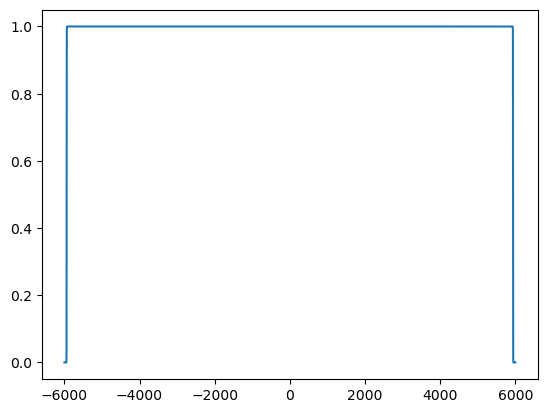

In [75]:
def step_fun(vx):
    low_x = np.amin(vx)*margin
    high_x = np.amax(vx)*margin
    xr = 1
    f = (1-1/( np.exp( (vx-low_x)/xr) + 1 ))*1/( np.exp( (vx-high_x)/xr) + 1 )
    return f

sf = step_fun(vx)
plt.plot(vx, sf)

(0.0, 2.0)

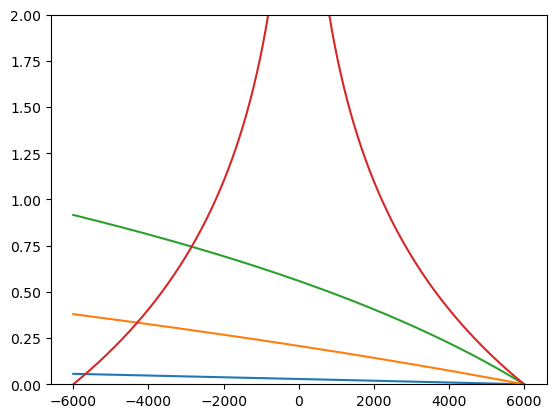

In [76]:
img1 = np.log( np.abs( vx - 2*6e3 - 2*100e3 + 1e-7 ) )
img2 = np.log( np.abs( vx - 2*6e3 - 2*10e3 + 1e-7 ) )
img3 = np.log( np.abs( vx - 2*6e3 - 2*1e3 + 1e-7 ) )
CC = -np.log( np.abs( vx + 1e-7 ) )
plt.plot(vx, img1-np.amin(img1) )
plt.plot(vx, img2-np.amin(img2) )
plt.plot(vx, img3-np.amin(img3) )
plt.plot(vx, CC-np.amin(CC))
plt.ylim(0,2)

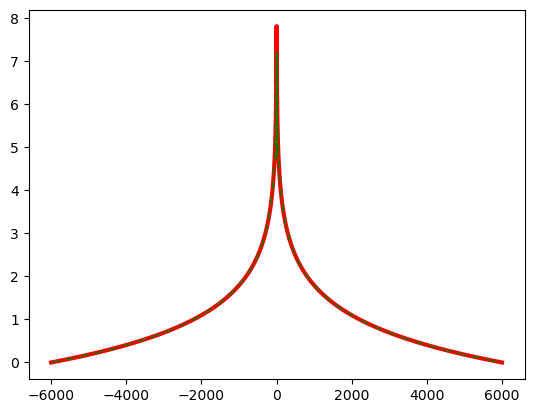

In [77]:
#mK_3D = kernel_3D(vx, vt, d, 1, dedge)
mK_0 = kernel_1D_0(vx, vt, d)

plt.plot(vx, np.fliplr(mK_0).diagonal(), color='red', linewidth=3 )
#plt.plot(vx, np.fliplr(mK_3D).diagonal(), color='blue', linestyle='--', linewidth=2 )
plt.plot(vx, np.fliplr(mK).diagonal(), color='green', linestyle='-.', linewidth=1 )
#plt.ylim(0,.2)
#plt.yscale('log')

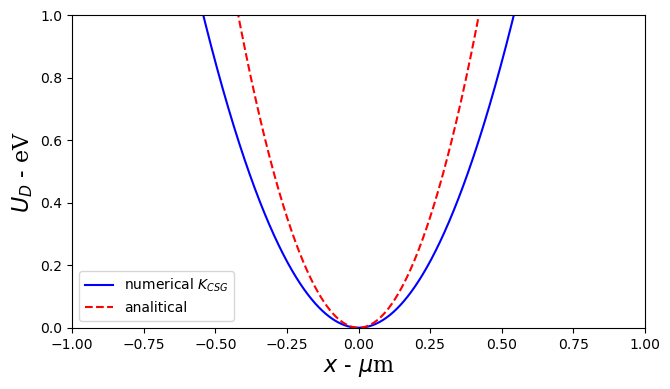

In [78]:
dx = np.abs(vx[1]-vx[0])
vUD_int = int_nonhomo_donor_U(vx, d, mK, num_D*np.ones(len(vx)), kappa0)


plt.plot(vx*1e-3, (vUD_int-np.amin(vUD_int))*1e-3, color='blue', label=r'numerical $K_{CSG}$')
plt.plot(vx*1e-3, (vUD-np.amin(vUD))*1e-3, color='red', linestyle='--', label=r'analitical')
plt.xlabel(r"$x$ - $\mu$m", fontdict=font)
plt.ylabel(r"$U_D$ - eV", fontdict=font)
plt.legend()
plt.gcf().set_size_inches(170 / 25.4, 100 / 25.4)
plt.tight_layout()
plt.ylim(0,1.)
plt.xlim(-1,1)
plt.savefig("U_donor.pdf")

In [79]:
vUD = vUD_int

(0.0, 0.0022730495711796353)

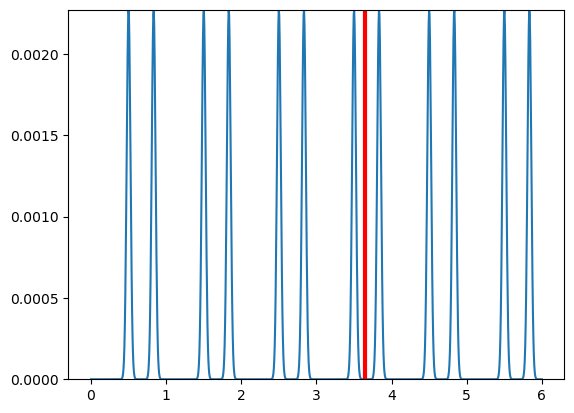

In [80]:
plt.plot(vE/omB, vD)
plt.vlines(filling0, ymin=0, ymax=np.amax(vD), color='red', linewidth=3)
plt.ylim(0,np.amax(vD))

In [81]:
vU_free = vUG + vUD

mu0 = omB*filling0 + np.amin(vUD)
D0 = 2.8 * 1e-4 #in meV^-1 nm^-2

arr_mu = mu0 + np.linspace(-.9999999, 2.,20000)*mu0
avg_num_e = np.zeros(len(arr_mu))
for nmu, mu in enumerate(arr_mu):
    #num_e_free = number_e(T, vx, vU_free, vD, vE, mu)
    v = mu - vU_free
    thet = w = np.where(v > 0, 1, 0)
    num_e_free = D0 * np.multiply ( (mu - vU_free), thet )
    dx = np.abs(vx[0]-vx[1])
    avg_num_e[nmu] = 1/(2*d)*dx*np.sum(num_e_free)
nmui = np.argmin( np.abs(avg_num_e - targ_num_e) )
mu = arr_mu[nmui]
print(avg_num_e[nmui]/targ_num_e, targ_num_e)
print(avg_num_e)
print(mu, np.amin(vUD))


1.0091257941017557 0.006500000000000001
[53.58033716 53.57009938 53.5598616  ...  0.          0.
  0.        ]
-243250.8829842377 -243783.29260442394


In [82]:
dx = np.abs(vx[0]-vx[1])
a0 = 10     #screening lenght in nm
vR = 1./(np.pi*a0) * mu * np.dot(mK, np.multiply(np.ones(len(vx)), sf ))*dx + vUD + vUG

matrix = np.eye(len(vx)) + 1./(np.pi*a0) * dx * np.multiply(mK, sf[np.newaxis,:])
M1 = scipy.linalg.inv(matrix)
vU = np.dot(M1, vR)

mu1 = mu
arr_mu = mu1 + np.linspace(-.9, 1.,10000)*mu1
avg_num_e = np.zeros(len(arr_mu))
D0 = 2.8 * 1e-4 #in meV^-1 nm^-2
for nmu, mu1 in enumerate(arr_mu):
    v = mu1 - vU
    thet = w = np.where(v > 0, 1, 0)
    num_e_free = D0 * np.multiply ( (mu1 - vU), thet )
    dx = np.abs(vx[0]-vx[1])
    avg_num_e[nmu] = 1/(2*d)*dx*np.sum(num_e_free)
nmui = np.argmin( np.abs(avg_num_e - targ_num_e) )
mu1 = arr_mu[nmui]

nxR = np.argmin(np.abs(vx-.9*d))
print(vU[nxR], np.amin(vU), mu1, mu)

-242232.4014704384 -243398.34110796868 -243326.29829949432 -243250.8829842377


In [83]:
Umin = np.amin(vU)
UDmin = np.amin(vUD)

vU = vU - np.amin(vU)
vUD = vUD - np.amin(vUD)

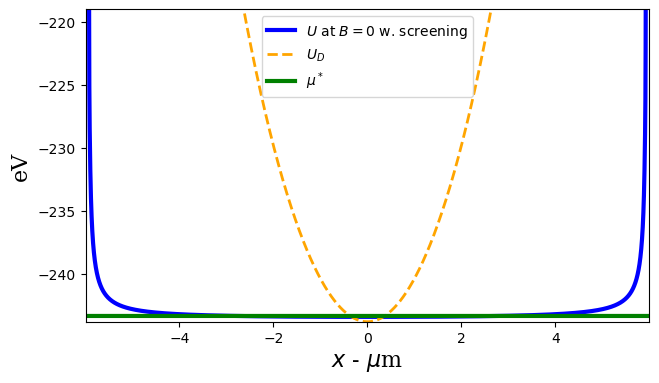

In [84]:
#norm = ED
plt.plot(vx*1e-3, (vU+Umin)*1e-3, color='blue', linewidth=3, label=r'$U$ at $B=0$ w. screening')
plt.plot(vx*1e-3, (vUD+UDmin)*1e-3, linestyle='--', color='orange', linewidth=2, label=r'$U_D$')
plt.plot(vx*1e-3, mu1*np.ones(len(vx))*1e-3, color='green', linewidth=3, label=r"$\mu^*$")
ymax = max(np.amax((vU+Umin)*1e-3), np.amax((vUD+UDmin)*1e-3) )
ymin = min( np.amin((vU+Umin)*1e-3), np.amin((vUD+UDmin)*1e-3)  )
#plt.ylim(ymin,ymax)
plt.ylim(ymin, .9*mu1*1e-3)
plt.xlim( np.amin(vx*1e-3), np.amax(vx*1e-3) )

plt.xlabel(r"$x$ - $\mu$m", fontdict=font)
plt.ylabel(r"eV", fontdict=font)
plt.legend()
plt.gcf().set_size_inches(170 / 25.4, 100 / 25.4)
plt.tight_layout()
plt.savefig("screenedUB0.pdf")

In [85]:
mu0 = omB*filling0

arr_mu = mu0 + np.linspace(-.5,3.,400)*mu0
avg_num_e = np.zeros(len(arr_mu))
for nmu, mu in enumerate(arr_mu):
    num_e_free = number_e(T, vx, vU, vD, vE, mu)
    dx = np.abs(vx[0]-vx[1])
    avg_num_e[nmu] = 1/(2*d)*dx*np.sum(num_e_free)
nmui = np.argmin( np.abs(avg_num_e - targ_num_e) )
mu = arr_mu[nmui]
print(avg_num_e[nmui]/targ_num_e, avg_num_e[nmui], targ_num_e)
print(avg_num_e)

0.9980011882351829 0.00648700772352869 0.006500000000000001
[0.00104133 0.00109688 0.00115224 0.00119742 0.00123657 0.00127236
 0.00130583 0.00133751 0.00136776 0.00139679 0.00142478 0.00145185
 0.0014781  0.00150362 0.00152846 0.00155269 0.00157635 0.00159949
 0.00162213 0.00164445 0.00166913 0.0017083  0.00176552 0.0018196
 0.00186409 0.00190335 0.00193964 0.00197386 0.00200648 0.00203784
 0.00206903 0.00210794 0.00216673 0.00223141 0.00228612 0.00233356
 0.00237711 0.00241807 0.00245707 0.0024945  0.0025306  0.00256555
 0.00259951 0.00263256 0.0026648  0.0026963  0.00272712 0.00275731
 0.0027869  0.00281595 0.00284453 0.00287406 0.00291405 0.00297424
 0.00303685 0.00308943 0.0031357  0.00317856 0.00321912 0.00325795
 0.00329538 0.00333204 0.00337316 0.00343238 0.00350357 0.00356661
 0.00362104 0.00367093 0.00371795 0.00376285 0.00380605 0.00384783
 0.00388838 0.00392787 0.00396639 0.00400405 0.00404092 0.00407706
 0.00411252 0.00414735 0.00418158 0.00421528 0.00424912 0.00428976
 0.

(0.0, 0.0022730495711796353)

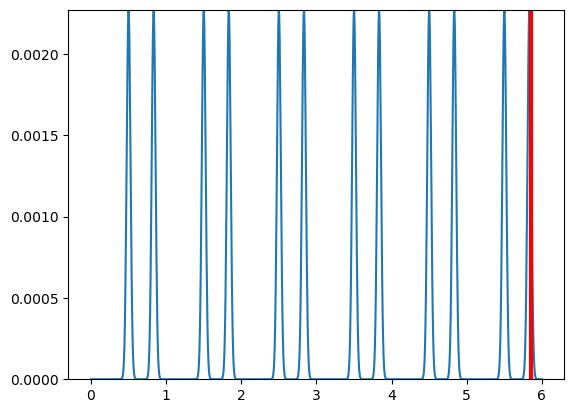

In [86]:
plt.plot(vE/omB, vD)
plt.vlines(mu/omB, ymin=0, ymax=np.amax(vD), color='red', linewidth=3)
plt.ylim(0,np.amax(vD))

In [87]:
set_num_threads(5)   # choose the number of threads
print(get_num_threads())  # verify

@njit(parallel=True, fastmath=True)  # fastmath optional but often helpful
def compute_avg_num_e(arr_mu, T, vx, vU, vD, vE, d):
    dx = abs(vx[0] - vx[1])   # use built-in abs, Numba handles it fine
    n_mu = arr_mu.size
    avg_num_e = np.empty(n_mu)   # allocate once

    list_num_e = np.zeros(shape=(len(arr_mu), len(vx)))
    for nmu in prange(n_mu):
        mu = arr_mu[nmu]
        num_e_free = number_e(T, vx, vU, vD, vE, mu)
        list_num_e[nmu] = num_e_free
        # use .sum() instead of np.sum() for slightly less overhead
        avg_num_e[nmu] = dx * num_e_free.sum() / (2.0 * d)

    return avg_num_e, list_num_e

@njit
def self_cons(T, d, vx, vD, vE, mu0, targ_num_e, kappa0, mK, vU, vUD, vUG, iterations):
    alpha = .0000025
    dx = np.abs(vx[0]-vx[1])
    v_mu = np.zeros(iterations)
    v_num_e = np.zeros(iterations)
    mu = mu0
    vnum_e_old = number_e(T, vx, vU, vD, vE, mu)
    for ni in range(iterations):
        
        arr_mu = mu + np.linspace(-.1,.1,20)*mu
        avg_num_e, list_num_e = compute_avg_num_e(arr_mu, T, vx, vU, vD, vE, d)
        nmui = np.argmin( np.abs(avg_num_e - targ_num_e) )
        mu = arr_mu[nmui]
        v_mu[ni] = mu
        #v_num_e[ni] = avg_num_e[nmui]
        vnum_e = list_num_e[nmui, :]
        #vnum_e = number_e(T, vx, vU, vD, vE, mu)


        vUnew = kappa0 * dx * np.dot(mK, vnum_e) + vUD + vUG
        Unewmin = np.amin(vUnew)
        #v_num_e[ni] = (np.sum( (vUnew-Unewmin - vU)**2 )*dx)/omB**2 #/(np.sum(vUnew-Unewmin)*np.sum(vU)*dx*dx )
        
        v_num_e[ni] = np.sum( (vnum_e_old-vnum_e)**2 )*dx
        vnum_e_old = vnum_e
        
        vU = alpha*(vUnew) + (1-alpha)*vU
        vU = vU - np.amin(vU)
    
    return v_mu, v_num_e, vU, vnum_e

iterations = 1000
v_mu, v_num_e, vU, vnum_e = self_cons(T, d, vx, vD, vE, mu, targ_num_e, kappa0, mK, vU, vUD, vUG, iterations)

5


In [88]:
mu_print = v_mu[-1]   # value you want in metadata

header = f"""Data file for U(x)
mu = {mu_print}
omB = {omB}
Columns:
1) x
2) U(x)
"""

np.savetxt(
    "Ux.dat",
    np.column_stack([vx, vU]),
    header=header,
    fmt="%.8e",          # scientific format (change if you prefer)
    comments="# "
)

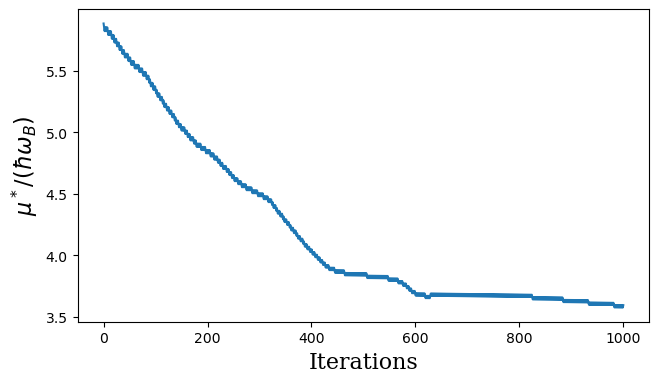

In [89]:
plt.plot(np.linspace(0,iterations, iterations), v_mu/omB)
plt.xlabel(r"Iterations", fontdict=font)
plt.ylabel(r"$\mu^*/(\hbar \omega_B)$", fontdict=font)
#plt.legend()
plt.gcf().set_size_inches(170 / 25.4, 100 / 25.4)
plt.tight_layout()
plt.savefig("conv_mu.pdf")

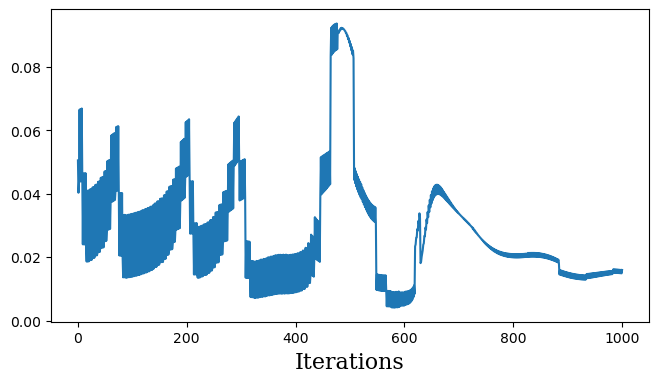

In [90]:
#plt.plot(np.linspace(0,iterations, iterations), 100*np.abs(v_num_e/(v_num_e[-1])-1.) )
plt.plot(np.linspace(0,iterations, iterations), 100*np.abs(v_num_e ) )
#plt.plot(np.linspace(0,iterations-1, iterations-1), 100*np.abs( (v_num_e[1:iterations]-v_num_e[0:iterations-1])/(v_num_e[1:iterations]+v_num_e[0:iterations-1] )) )
#plt.yscale('log')
plt.xlabel(r"Iterations", fontdict=font)
#plt.ylabel(r"$|\delta \bar{n}_e/\bar{n}_e - 1|$  %", fontdict=font)
#plt.ylabel(r"$|\bar{n}_e^{(j+1)}-\bar{n}_e^{(j)}|/|\bar{n}_e^{(j+1)}+\bar{n}_e^{(j)}|$  %", fontdict=font)
#plt.legend()
plt.gcf().set_size_inches(170 / 25.4, 100 / 25.4)
plt.tight_layout()
plt.savefig("conv_esti.pdf")

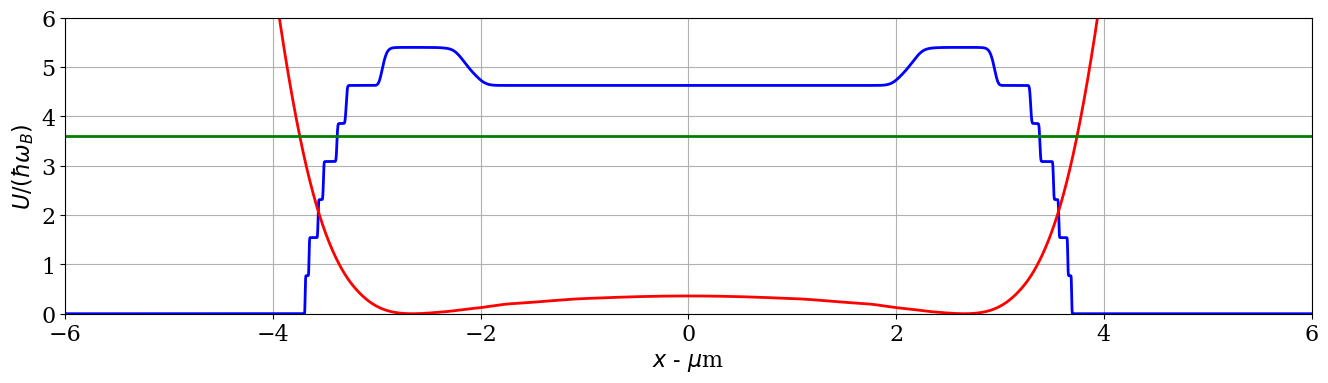

In [91]:
ymax = 6
plt.plot( vx*1e-3, vnum_e/np.amax(vnum_e)*ymax*9./10., color='blue', linewidth=2 )
#plt.plot(vx, vU/omB + 1e1*np.log(np.abs( (vx-1600)/1000 ))*np.exp(-np.abs( (vx-1600)/1000) ), color='red', linewidth=2)
plt.plot(vx*1e-3, vU/omB , color='red', linewidth=2)
plt.hlines(v_mu[-1]/omB, xmin=-d, xmax=d, color='green', linewidth=2)
#plt.plot(vx, vUD/omB, linestyle='--')
plt.ylim(0,ymax)
plt.xlim(-d*1e-3,d*1e-3)

font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}
plt.xlabel(r"$x$ - $\mu$m", fontdict=font)
plt.ylabel(r"$U/(\hbar \omega_B)$", fontdict=font)
# Customize tick labels
plt.xticks(fontsize=font['size'], fontname=font['family'], weight=font['weight'], color=font['color'])
plt.yticks(fontsize=font['size'], fontname=font['family'], weight=font['weight'], color=font['color'])
plt.grid()

plt.gcf().set_size_inches(340 / 25.4, 100 / 25.4)
plt.tight_layout()

#plt.savefig("eff_conf.pdf")

In [92]:
print(targ_num_e, np.sum(vnum_e)*dx/(2.*d))

0.006500000000000001 0.006512515853061451


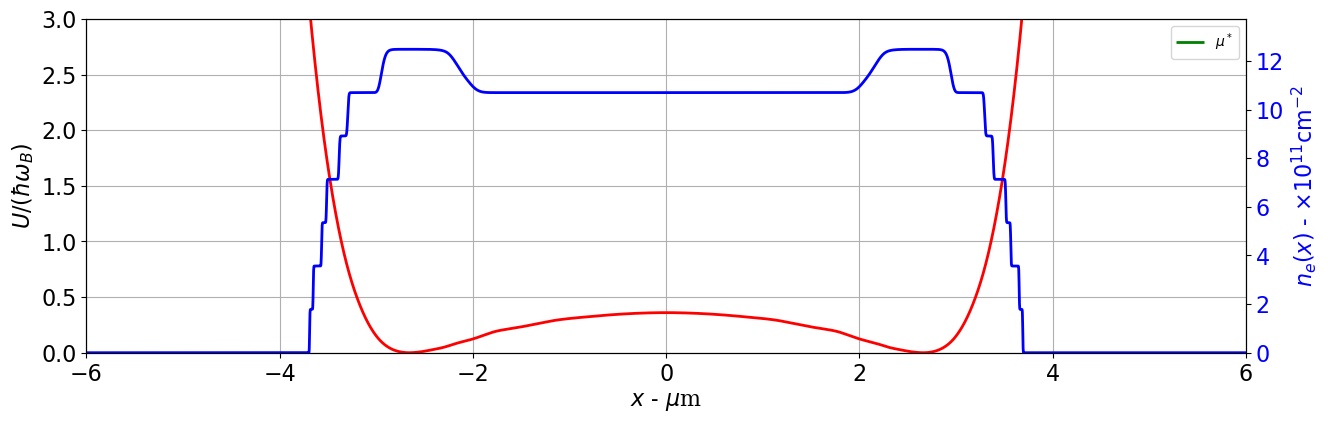

In [93]:
ymax = 3

fig, ax = plt.subplots()

# --- LEFT Y-AXIS (potential) ---
ax.plot(vx*1e-3, vU/omB, color='red', linewidth=2)
ax.hlines(v_mu[-1]/omB, xmin=-d*1e-3, xmax=d*1e-3,
          color='green', linewidth=2, label=r"$\mu^*$")

ax.set_ylim(0, ymax)
ax.set_xlim(-d*1e-3, d*1e-3)

# --- RIGHT Y-AXIS (blue curve) ---
ax2 = ax.twinx()
ax2.plot(
    vx*1e-3,
    vnum_e*1e3,
    color='blue',
    linewidth=2
)

ax2.set_ylim(0, np.amax(vnum_e*1e3)*1.1)   # same scale for visual alignment
ax2.tick_params(axis='y', labelcolor='blue')



ax.set_xlabel(r"$x$ - $\mu$m", fontdict=font)
ax.set_ylabel(r"$U/(\hbar \omega_B)$", fontdict=font)
ax2.set_ylabel(r"$n_e(x)$ - $\times 10^{11} {\rm cm}^{-2}$", fontdict=font, color='blue')

# --- Tick styling ---
ax.tick_params(axis='both',
               labelsize=font['size'],
               labelcolor=font['color'])
ax2.tick_params(axis='y',
                labelsize=font['size'],
                labelcolor='blue')

ax.grid()
ax.legend()

# --- Figure size ---
fig.set_size_inches(340 / 25.4, 110 / 25.4)
fig.tight_layout()

plt.savefig("U_CSG1.pdf")

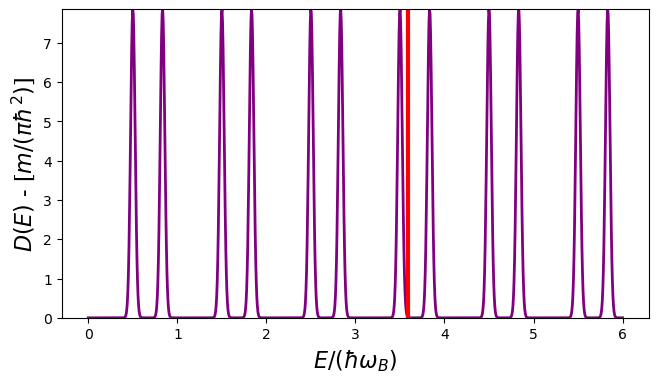

In [94]:
plt.plot(vE/omB, np.pi*lB**2*omB*vD, color='purple', linewidth=2)
plt.vlines(v_mu[-1]/omB, ymin=0, ymax=np.amax(np.pi*lB**2*omB*vD), color='red', linewidth=3)
plt.ylim(0,np.pi*lB**2*omB*np.amax(vD))

plt.xlabel(r"$E/(\hbar\omega_B)$", fontdict=font)
plt.ylabel(r"$D(E)$ - [$m/(\pi \hbar^2)$]", fontdict=font)
#plt.legend()
plt.gcf().set_size_inches(170 / 25.4, 100 / 25.4)
plt.tight_layout()
plt.savefig("DOS_mu.pdf")

In [95]:
def ffddddmu_dnumber_e(T, vx, vU, vD, vE, mu):    #T in meV
    dnum_e = np.zeros(len(vx))
    
    dE = np.abs(vE[0]-vE[1])
    zpE = .5*omB*0
    if T > .01:
        for ne, E1 in enumerate(vE):
            E = E1 - zpE
            #dF = np.exp( (E + vU - mu)/T ) /( np.exp( (E + vU - mu)/T ) + 1. )**2./T 
            logdFT = ( (E + vU - mu)/T ) - np.log( np.exp( (E + vU - mu)/T ) + 1. )*2.
            dF = np.exp(logdFT)/T
            dnum_e += dE*vD[ne] * dF
    else:
        for nx, x in enumerate(vx):
            ne = np.argmin(np.abs(vE- zpE - (mu - vU[nx] ) ))
            dnum_e[nx] = vD[ne]
    
    return dnum_e

dnum_e = ffddddmu_dnumber_e(T, vx, vU, vD, vE, mu)


/var/folders/y4/dpq6l9fj2kv9z0prq_6_pyy00000gn/T/ipykernel_39981/2635813459.py:10: RuntimeWarning: overflow encountered in exp
  logdFT = ( (E + vU - mu)/T ) - np.log( np.exp( (E + vU - mu)/T ) + 1. )*2.


/var/folders/y4/dpq6l9fj2kv9z0prq_6_pyy00000gn/T/ipykernel_39981/2635813459.py:10: RuntimeWarning: overflow encountered in exp
  logdFT = ( (E + vU - mu)/T ) - np.log( np.exp( (E + vU - mu)/T ) + 1. )*2.


51.45542224591898


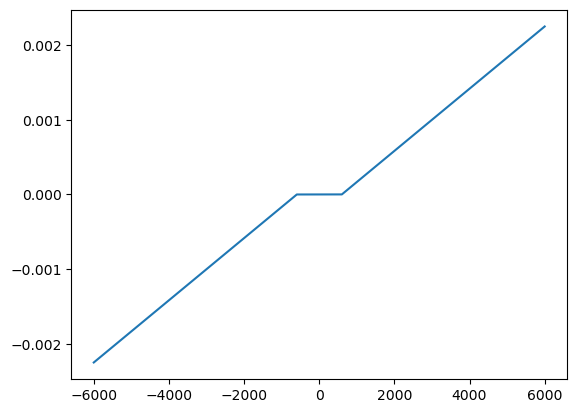

In [96]:
#vnum_e = number_e(T, vx, vU, vD, vE, mu)
#dnum_e = ddddmu_dnumber_e(T, vx, vU, vD, vE, mu)
dnum_e = ffddddmu_dnumber_e(T, vx, vU, vD, vE, v_mu[-1])


#mK_1D = kernel_1D_image(vx, vt, d, 10000)

mKcomp = mK


#dnum_e = number_e(T, vx, vU, vD, vE, mu)

matrix_inv = np.eye(len(vx)) +  kappa0 * dx * np.multiply(mKcomp , dnum_e[np.newaxis, :])
MMmatrix = scipy.linalg.inv(matrix_inv)
#MMmatrix = np.eye(len(vx))

UH = .001
delta_mu = np.zeros(len(vx))
dddmu = .1
mask1 = vx > d*dddmu
mask2 = vx < -d*dddmu
delta_mu[mask1] = UH * (vx[mask1]-d*dddmu)/(2*d*.2)
delta_mu[mask2] = UH * (vx[mask2]+d*dddmu)/(2*d*.2)



#dU = - UH * kappa0 * dx * np.dot(mK, np.multiply(vx/(2*d), dnum_e ) )
dU = -  kappa0 * dx * np.dot(mKcomp, np.multiply(delta_mu, dnum_e ) )
dU = np.matmul(MMmatrix, dU)

print(np.amax(np.abs(MMmatrix)))

plt.plot(vx, delta_mu)


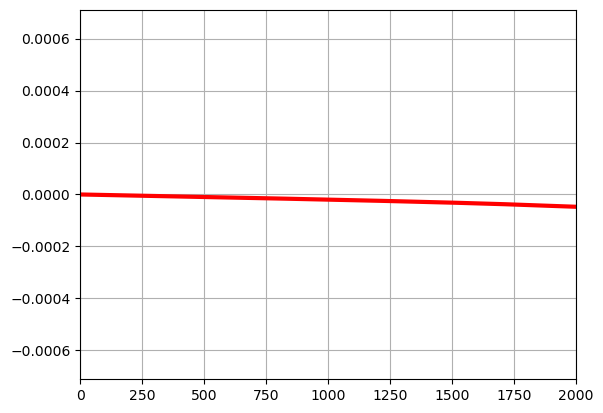

In [97]:
#plt.ylim(-.1,.0)
#plt.xlim(00,1000)
plt.plot( vx, (dU)/omB, color='red', linewidth=3 )
#plt.plot( vx, (vU)/omB, color='blue', linewidth=1, linestyle='--' )

plt.xlim(0,2000)
plt.grid()

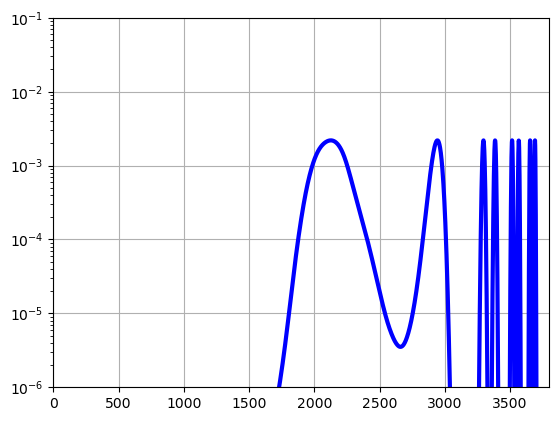

In [98]:
#delta_num_e = np.multiply(dnum_e, - UH*vx/(2*d) + dU )
delta_num_e = np.multiply(dnum_e, (delta_mu - dU) )

plt.plot( vx, dnum_e, color='blue', linewidth=3 )

plt.yscale('log')
plt.ylim(1e-6,1e-1)
plt.xlim(0,3800)


plt.grid()

0.9658901423950418


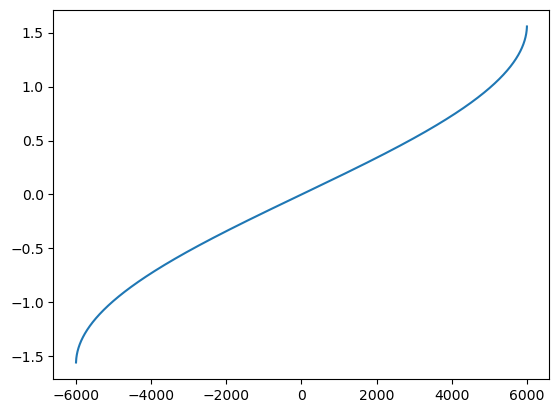

In [99]:
Tfun = np.arctan(np.sqrt((d+vx)/(d-vx) ) ) - np.arctan(np.sqrt((d-vx)/(d+vx) ) )
plt.plot(vx,Tfun)

Vhall = 2/np.pi*kappa0 * np.sum( delta_num_e*Tfun )*dx
print(Vhall)

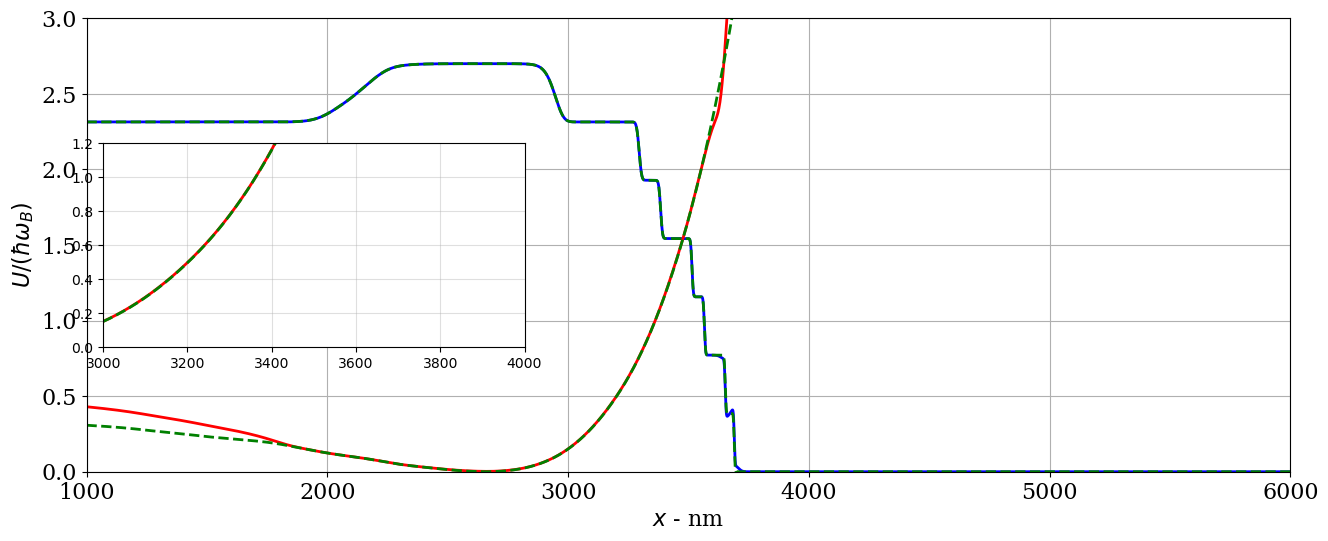

In [100]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.ndimage import gaussian_filter

ymax = 3


tot_num_e = vnum_e + np.multiply(dnum_e, - UH*vx/(2*d) + dU )
dmetal = 200
ne_1s = 1./(lB) * 1e-1  #1D electron density ( multiplied by scaling factor lB/L_distance )
#Uimg_cond = -kappa0/2./np.abs(vx-d-dmetal) * 100 #/(1.+100*dnum_e)
Uimg_cond = kappa0*np.log( np.abs( (np.sqrt( (d**2 - vx**2.)*(d**2.-vx**2) ) + d**2 - vx*vx )/(2*d**2) ) ) * ne_1s
Uimg_cond = Uimg_cond - np.amax(Uimg_cond)

Uimg_screen = np.matmul(MMmatrix, Uimg_cond)

delta_N = dnum_e * Uimg_screen

smoothN = gaussian_filter(delta_N, sigma=10.)

smoothU = gaussian_filter(vU+Uimg_screen, sigma=10.)
#smoothU = vU*0+Uimg_screen


plt.plot( vx, (tot_num_e-smoothN)/np.amax(tot_num_e-smoothN)*ymax*9./10., color='blue', linewidth=2 )
plt.plot( vx, (tot_num_e)/np.amax(tot_num_e)*ymax*9./10., color='green', linestyle='--', linewidth=2 )

#plt.plot(vx, vU/omB + 1e1*np.log(np.abs( (vx-1600)/1000 ))*np.exp(-np.abs( (vx-1600)/1000) ), color='red', linewidth=2)
#plt.plot(vx, (vU+dU)/omB , color='red', linewidth=2)
plt.plot(vx, (smoothU)/omB , color='red', linewidth=2)
plt.plot(vx, (vU)/omB , color='green', linewidth=2, linestyle='--')







plt.hlines(v_mu[-1]/omB, xmin=-d, xmax=d, color='green', linewidth=2)
#plt.plot(vx, vUD/omB, linestyle='--')
plt.ylim(-.0,ymax)
plt.xlim(1000,6000)

font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}
plt.xlabel(r"$x$ - nm", fontdict=font)
plt.ylabel(r"$U/(\hbar \omega_B)$", fontdict=font)
# Customize tick labels
plt.xticks(fontsize=font['size'], fontname=font['family'], weight=font['weight'], color=font['color'])
plt.yticks(fontsize=font['size'], fontname=font['family'], weight=font['weight'], color=font['color'])
plt.grid()

plt.gcf().set_size_inches(340 / 25.4, 140 / 25.4)
plt.tight_layout()



ax = plt.gca()

# --- inset: right side, vertically centered ---
axins = inset_axes(
    ax,
    width="35%", height="45%",              # size of inset (tweak as you like)
    loc="center left",                     # right side, centered vertically
    borderpad=1.2
)

# plot ONLY the red curve in the inset (or add the blue too if you want)
axins.plot(vx, (smoothU)/omB, color="red", linewidth=2)
axins.plot(vx, (vU)/omB, color="green", linewidth=2, linestyle='--')


# zoom limits
axins.set_xlim(3000, 4000)
axins.set_ylim(0., 1.2)

# optional: make inset cleaner
axins.grid(True, alpha=0.4)
axins.tick_params(labelsize=10)

# optional: draw a box on the main plot showing the zoomed region + connectors
#mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.4")



plt.savefig("U_perturb1.pdf")

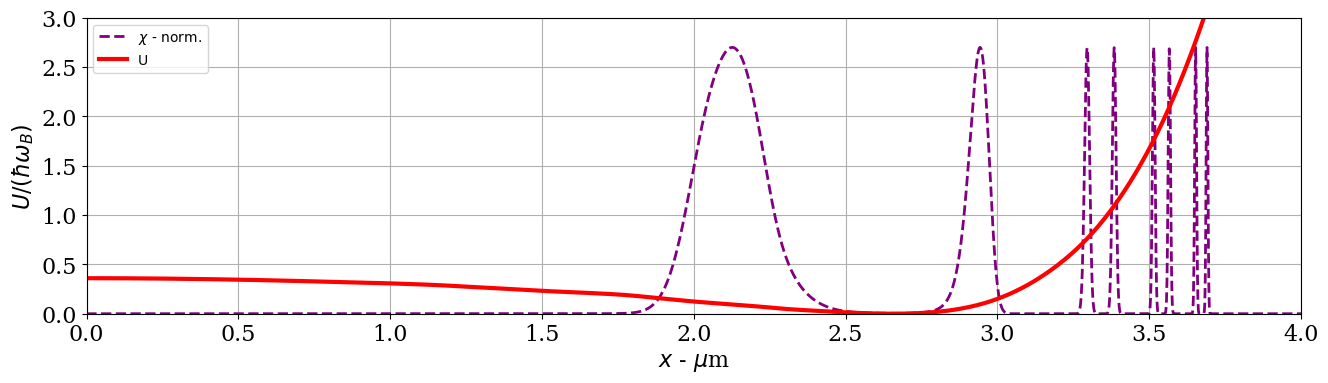

In [101]:
ymax = 3

tot_num_e = vnum_e - UH*np.multiply(vx/(2*d), dnum_e)

plt.plot( vx*1e-3, dnum_e/np.amax(dnum_e)*ymax*9./10., linestyle='--', color='purple', linewidth=2, label=r"$\chi$ - norm." )
#plt.plot( vx*1e-3, delta_num_e/np.amax(delta_num_e)*ymax*9./10., color='blue', linewidth=2, label=r"$\Delta n_e$ - norm." )

#plt.plot(vx, vU/omB + 1e1*np.log(np.abs( (vx-1600)/1000 ))*np.exp(-np.abs( (vx-1600)/1000) ), color='red', linewidth=2)
plt.plot(vx*1e-3, (vU+dU)/omB , color='red', linewidth=3, label=r"U")
#plt.hlines(v_mu[-1]/omB, xmin=-d, xmax=d, color='green', linewidth=2, label=r"$\mu^*$")

plt.ylim(0,ymax)
#plt.xlim(0,d*1e-3)
plt.xlim(0,4)

font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}
plt.xlabel(r"$x$ - $\mu$m", fontdict=font)
plt.ylabel(r"$U/(\hbar \omega_B)$", fontdict=font)
# Customize tick labels
plt.xticks(fontsize=font['size'], fontname=font['family'], weight=font['weight'], color=font['color'])
plt.yticks(fontsize=font['size'], fontname=font['family'], weight=font['weight'], color=font['color'])
plt.grid()
plt.legend()

plt.gcf().set_size_inches(340 / 25.4, 100 / 25.4)
plt.tight_layout()
plt.savefig("Uchin_zoom_perturb1.pdf")

In [102]:
print( np.sum(vnum_e)*dx, targ_num_e*2*d )

78.15019023673742 78.0


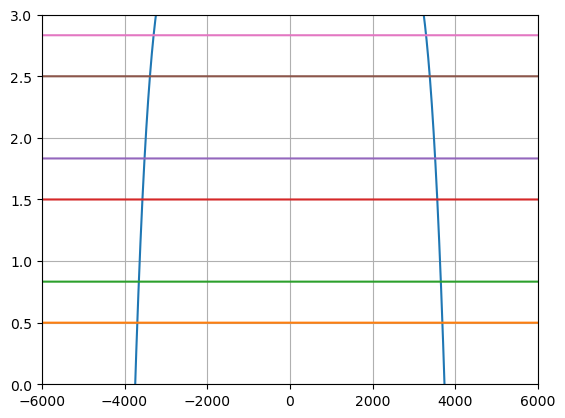

In [103]:
plt.plot(vx, v_mu[-1]/omB-vU/omB)
plt.ylim(0,3)
plt.xlim(-6000,6000)

plt.plot(vx, np.ones(len(vx))*.5)
plt.plot(vx, np.ones(len(vx))*.5+.333)

plt.plot(vx, np.ones(len(vx))*1.5)
plt.plot(vx, np.ones(len(vx))*1.5+.333)

plt.plot(vx, np.ones(len(vx))*2.5)
plt.plot(vx, np.ones(len(vx))*2.5+.333)






plt.grid()



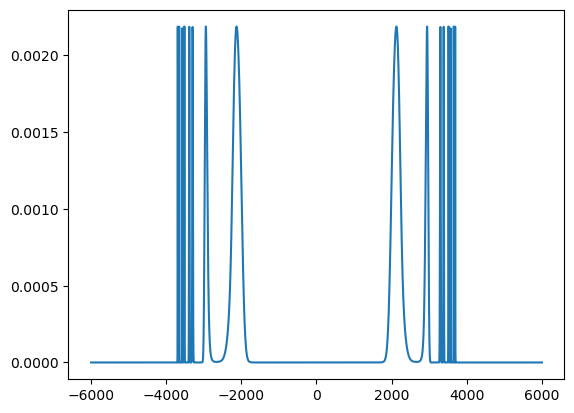

In [104]:
plt.plot(vx, dnum_e)

(0.0, 5.0)

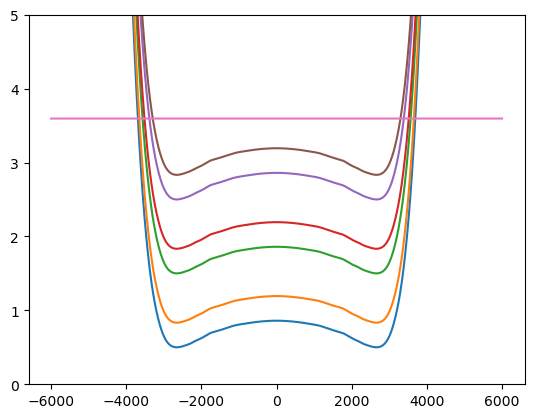

In [105]:
plt.plot(vx, vU/omB+.5)
plt.plot(vx, vU/omB+.5+.333)

plt.plot(vx, vU/omB+1.5)
plt.plot(vx, vU/omB+1.5+.333)

plt.plot(vx, vU/omB+2.5)
plt.plot(vx, vU/omB+2.5+.333)
plt.plot(vx, np.ones(len(vx))*v_mu[-1]/omB)

plt.ylim(0,5)

In [106]:
mu_print = v_mu[-1]

header = f"""Data file for U(x)
mu = {mu_print}
omB = {omB}
Columns:
1) x
2) U(x)
3) local density n_e(x)
4) compressibility dn_e(x)
"""

np.savetxt(
    "Ux.dat",
    np.column_stack([vx, vU, vnum_e, dnum_e]),
    header=header,
    fmt="%.8e",
    comments="# "
)